# 2.2 Choosing the score

We now have two models reading every target sentence. FinBERT scores the sentence, and ABSA
scores sentiment toward an aspect we hand it explicitly. They turn out to be good at different
halves of the job.

We measure how far apart they are, build eight candidate combinations, narrow to one with 300 blind
hand labels, and then fix the one parameter nobody had tested.

We drew the sample from strata that include `is_comparative`, a column we dropped in `b1fcc6f`, so
this notebook is read rather than re-run. The frame is frozen, as described in section 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from news_sentiment.config import DATA_DIR, PROJ_ROOT, REPORTS_DIR
from news_sentiment.text.fusion import score_variants, signed, VARIANTS

pd.set_option("display.max_colwidth", 200)

sentences = pd.read_parquet(DATA_DIR / "sentences.parquet")
print("sentences:", sentences.shape)
print("variants:", VARIANTS)

2026-08-16 17:37:41.344 | INFO     | news_sentiment.config:<module>:12 - PROJ_ROOT path is: D:\ML\stock-predictor


sentences: (71410, 24)
variants: ('fin', 'absa', 'mean_blend', 'sign_graft', 'conf_graft', 'conf_graft_soft', 'gated', 'agree_only')


In [ ]:
# Section 1 was run against the same table under the name `scored_sentences`.
scored_sentences = sentences

### 1. How far apart the two scorers are

If the two models mostly agree, the choice between them is cosmetic and any blend will do.

In [16]:
tgt = scored_sentences[
    scored_sentences["mentions_target"] & ~scored_sentences["is_boilerplate"]
].dropna(subset=["pos", "neg", "absa_pos", "absa_neg"])

fin_signed = tgt["pos"] - tgt["neg"]
absa_signed = tgt["absa_pos"] - tgt["absa_neg"]

print(f"target sentences with both scores: {len(tgt)}")
print()
print("mean probabilities over target sentences")
print(pd.DataFrame({
    "FinBERT": [tgt["pos"].mean(), tgt["neg"].mean(), tgt["neu"].mean()],
    "ABSA": [tgt["absa_pos"].mean(), tgt["absa_neg"].mean(), tgt["absa_neu"].mean()],
}, index=["pos", "neg", "neu"]).round(4))
print()
print(f"correlation of signed sentiment: {fin_signed.corr(absa_signed):.3f}")

target sentences with both scores: 13947

mean probabilities over target sentences
     FinBERT    ABSA
pos   0.3089  0.1616
neg   0.2480  0.1789
neu   0.4432  0.6596

correlation of signed sentiment: 0.493


ABSA puts far more of the corpus in the neutral bucket than FinBERT does, at 0.660 against 0.443,
which is what an aspect-scoped reading should do, since most sentences that mention a company
express no sentiment toward that company. The two signed scores correlate at 0.493.

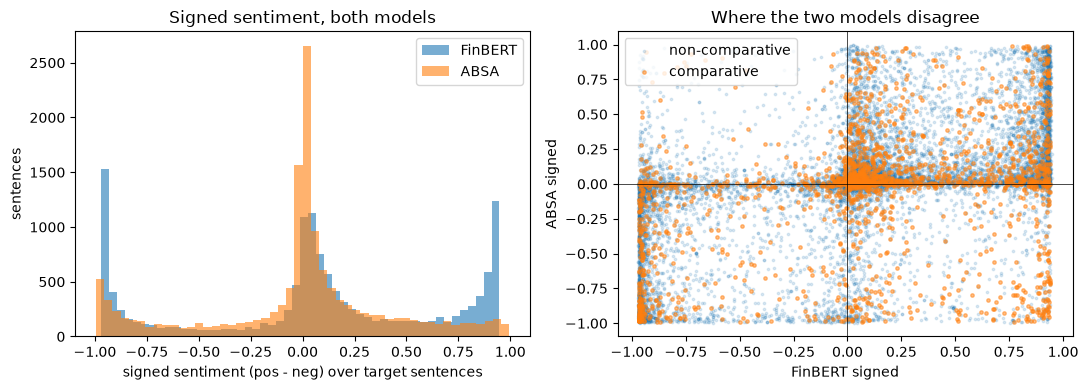

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(fin_signed, bins=50, alpha=0.6, label="FinBERT")
axes[0].hist(absa_signed, bins=50, alpha=0.6, label="ABSA")
axes[0].set_xlabel("signed sentiment (pos - neg) over target sentences")
axes[0].set_ylabel("sentences")
axes[0].set_title("Signed sentiment, both models")
axes[0].legend()

comp_mask = tgt["is_comparative"]
axes[1].scatter(fin_signed[~comp_mask], absa_signed[~comp_mask], s=3, alpha=0.15,
                label="non-comparative")
axes[1].scatter(fin_signed[comp_mask], absa_signed[comp_mask], s=6, alpha=0.5,
                label="comparative")
axes[1].axhline(0, lw=0.5, color="k")
axes[1].axvline(0, lw=0.5, color="k")
axes[1].set_xlabel("FinBERT signed")
axes[1].set_ylabel("ABSA signed")
axes[1].set_title("Where the two models disagree")
axes[1].legend()

plt.tight_layout()
fig.savefig(REPORTS_DIR / "figures" / "2.3-finbert-vs-absa.png", dpi=120)
plt.show()

In [18]:
# Sign disagreement, split by whether the sentence is a registry comparative.
disagree = ((fin_signed > 0) & (absa_signed < 0)) | ((fin_signed < 0) & (absa_signed > 0))
rate = pd.DataFrame({
    "n": [int((~comp_mask).sum()), int(comp_mask.sum())],
    "sign disagreement": [
        float(disagree[~comp_mask].mean()),
        float(disagree[comp_mask].mean()),
    ],
}, index=["non-comparative", "comparative"])
rate.round(4)

,n,sign disagreement
non-comparative,11892,0.2318
comparative,2055,0.3085


The two models disagree on the sign of sentiment for 23.2% of ordinary target sentences, and that
is the number `fusion.py` exists for. Comparative sentences disagree more, at 30.9%, which is the
effect we predicted, but the base rate is the finding. Nearly a quarter of plain, non-comparative
sentences split the two models, which is far too many to be explained by the 2,055 comparative rows.

The comparative split is no longer computable, since `is_comparative` went with other-company
detection, but the pooled claim is what matters and it survives.

A disagreement is not evidence that ABSA is right. It establishes only that the choice between them
is consequential. At this point the evidence about who is right was 25 hand-adjudicated sentences,
every one of them selected because the models disagreed, which is the most favourable possible
sample for whichever model wins disagreements. Corpus-wide, around 2,800 sentences disagree, so
everything we believed about the other 2,775 was extrapolation. Closing that gap is the rest of the
notebook.

### 2. Eight candidates

We define all eight per sentence rather than per article. That is deliberate, because we validate
them by reading individual sentences and asking whether the number attached to each one is sane,
and a feature that only exists as an article-level average cannot be inspected that way.

Writing `fin = pos - neg` and `absa = absa_pos - absa_neg`:

- **`fin`** is `pos - neg`, the FinBERT baseline.
- **`absa`** is `absa_pos - absa_neg`, the ABSA baseline.
- **`mean_blend`** is `(fin + absa) / 2`, a deliberately naive baseline.
- **`sign_graft`** is `sign(absa) * abs(fin)`: direction from ABSA, intensity from FinBERT.
- **`conf_graft`** is `absa * abs(fin)`, the same graft scaled by ABSA's own confidence.
- **`conf_graft_soft`** is `sign(absa) * abs(fin) * (0.5 + 0.5*abs(absa))`, the same with a gentler
  ramp.
- **`gated`** is `fin * (1 - absa_neu)`, FinBERT faded by ABSA's confidence.
- **`agree_only`** is `fin` where the signs agree and 0 otherwise.

Two of them need their reasoning stated first, because the results turn on it.

`sign_graft` is a graft rather than a product. `fin * absa` returns +0.81 for two scores of -0.9,
which turns a sentence both models call bad news into a strongly positive one, so we take the sign
of one and the magnitude of the other separately.

`gated` was the variant we expected to win. The contamination class is broader than any comparative
flag can catch, since it covers any pairing of the target with a benchmark, an ETF, a peer average
or a grade, so deleting the sentences we can detect is a crude binary version of something that
should be continuous. `gated` keeps FinBERT's magnitude where ABSA is confident and fades it where
ABSA is not. Note the property that decides it later: `1 - absa_neu` is non-negative, so `gated` can
only shrink a score and can never flip it.

### 3. The sample

We draw from the target sentences the pipeline actually scores, meaning `mentions_target`, not
boilerplate, with both models present.

Most of that population is sentences where the two models agree and every variant returns nearly
the same number, so a representative sample would spend most of its 300 rows on cases that cannot
separate the variants at all. We oversample the cases where they come apart, include control blocks
to catch errors that all variants share, and reweight every headline number to each stratum's true
corpus share before reporting it.

- **`disagree_comparative`**: signs differ and the sentence names a rival. This is the population
  the whole ABSA case rests on.
- **`disagree_plain`**: signs differ with no rival named, because contamination is broader than
  comparatives.
- **`absa_flat`**: `abs(absa) < 0.10`, which is exactly the set `sign_graft`'s deadband suppresses.
- **`resolved`**: tagged through coreference, so ABSA read a substituted sentence.
- **`agree_strong`** and **`agree_weak`**: controls.

We take 50 per stratum, capped at 2 per article so no long article dominates, with seed `20260816`.

Do not redraw this sample. The 900 labels in `references/fusion-labels*.csv` are keyed by
`sample_id` alone, so the frame is what gives them meaning, and redrawing against the current
schema would rebind every label to a different sentence. The frame is frozen at
`references/fusion-sample-frozen.csv`, rebuilt from the corpus as it stood at commit `94228ec` and
checked against all four label files.

`references/fusion-sample-frozen.csv`, which held the 300 sampled sentences, was deleted on
2026-08-21 along with the other labelling inputs. The labels are kept, and every `sample_id` encodes
its stratum, article and sentence index, so the sample is reconstructible from the sentence table:
all 300 rows still rejoin to the current corpus. The cells below that read the frozen file no longer
run, and their stored output is the record.

In [2]:
SEED = 20260816
N_PER_STRATUM = 50
MAX_PER_ARTICLE = 2

pop = sentences[
    sentences["mentions_target"]
    & ~sentences["is_boilerplate"]
    & sentences["pos"].notna()
    & sentences["absa_pos"].notna()
].copy()

pop["fin_raw"] = signed(pop["pos"], pop["neg"])
pop["absa_raw"] = signed(pop["absa_pos"], pop["absa_neg"])
pop["is_resolved"] = pop["resolved_by_coref"]

same_sign = np.sign(pop["fin_raw"]) == np.sign(pop["absa_raw"])
absa_flat = pop["absa_raw"].abs() < 0.10

print(f"population: {len(pop)} target, non-boilerplate, both-scored sentences")
print(f"  sign disagreement : {int((~same_sign).sum())} ({100*(~same_sign).mean():.1f}%)")
print(f"  |absa| < 0.10     : {int(absa_flat.sum())} ({100*absa_flat.mean():.1f}%)")

population: 13947 target, non-boilerplate, both-scored sentences
  sign disagreement : 3390 (24.3%)
  |absa| < 0.10     : 6106 (43.8%)


In [3]:
stratum = pd.Series("", index=pop.index, dtype=object)

def assign(name, mask):
    global stratum
    stratum = stratum.where(~((stratum == "") & mask), name)

assign("disagree_comparative", (~same_sign) & pop["is_comparative"])
assign("disagree_plain", ~same_sign)
assign("absa_flat", absa_flat)
assign("resolved", pop["is_resolved"])
assign("agree_strong", same_sign & (pop["fin_raw"].abs() >= 0.5))
assign("agree_weak", same_sign)
pop["stratum"] = stratum

STRATA = ["disagree_comparative", "disagree_plain", "absa_flat",
          "resolved", "agree_strong", "agree_weak"]
pop_sizes = pop["stratum"].value_counts()
weights = (pop_sizes / pop_sizes.sum()).to_dict()

print("stratum sizes in the population, and their corpus weight:")
for st in STRATA:
    print(f"  {st:<22} {pop_sizes[st]:>5}  {100*weights[st]:>5.1f}%")

stratum sizes in the population, and their corpus weight:
  disagree_comparative     634    4.5%
  disagree_plain          2756   19.8%
  absa_flat               4233   30.4%
  resolved                1277    9.2%
  agree_strong            3186   22.8%
  agree_weak              1861   13.3%


In [4]:
rng = np.random.default_rng(SEED)
picked = []
for name in STRATA:
    block = pop[pop["stratum"] == name]
    order = rng.permutation(len(block))
    per_article, chosen = {}, []
    for pos_i in order:
        if len(chosen) >= N_PER_STRATUM:
            break
        aid = block.iloc[pos_i]["article_id"]
        if per_article.get(aid, 0) >= MAX_PER_ARTICLE:
            continue
        per_article[aid] = per_article.get(aid, 0) + 1
        chosen.append(pos_i)
    picked.append(block.iloc[chosen])

sample = pd.concat(picked)
sample["sample_id"] = (
    sample["stratum"] + "-" + sample["article_id"].astype(str)
    + "-" + sample["sent_idx"].astype(str)
)
sample = sample.sort_values("sample_id").reset_index(drop=True)
print(f"sample: {len(sample)} rows, {sample['stratum'].nunique()} strata")
print(sample["stratum"].value_counts().to_string())

sample: 300 rows, 6 strata
stratum
absa_flat               50
agree_strong            50
agree_weak              50
disagree_comparative    50
disagree_plain          50
resolved                50


In [5]:
labels = pd.read_csv(PROJ_ROOT / "references" / "fusion-labels.csv")
print("labels:", labels.shape)

scores = score_variants(sample)
df = pd.concat([sample.reset_index(drop=True), scores.reset_index(drop=True)], axis=1)
df = df.merge(labels, on="sample_id", how="inner")
assert len(df) == 300, f"join lost rows: {len(df)} -- sample and labels disagree"
print("joined:", df.shape)
print()
print("label distribution:")
print(df["label"].value_counts().sort_index().to_string())

directional = df[df["label"] != 0]
neutral = df[df["label"] == 0]
print(f"\ndirectional rows (label != 0): {len(directional)}   neutral rows: {len(neutral)}")

labels: (300, 2)
joined: (300, 38)

label distribution:
label
-1.0     53
-0.5     55
 0.0    110
 0.5     46
 1.0     36

directional rows (label != 0): 190   neutral rows: 110


### 4. Blind labelling

We read each of the 300 sentences and gave it a score on a five-point scale for sentiment toward
Tesla, financially: +1.0 clearly good news, +0.5 mildly good, 0.0 none, -0.5 mildly bad, and -1.0
clearly bad.

Three properties of the protocol decide whether the resulting numbers mean anything.

- **Blind.** The sheet carried the `sample_id`, the aspect and the sentence text, and nothing else.
  No `pos` or `neg`, no `absa_*`, no variant scores, no `absa_text`, which would have leaked what
  the pipeline believed a mention resolved to, and no stratum. Anyone shown a model's answer tends
  to agree with it, and the exercise would then measure agreement rather than correctness.
- **Toward the target, not of the sentence.** "BYD capitalized on Tesla's weakness" is a positive
  sentence and a negative one about Tesla, and that distinction is the whole subject here.
- **Five points rather than three.** A three-way scheme could only test direction, and the
  hypothesis is specifically that FinBERT contributes better intensity, which needs labels that
  rank strength.

We designed the variants and also did the labelling. Blind labelling removes the mechanical route
by which that could bias the result, since no score was visible when any judgement was made, but
the hypothesis was written before the labelling, so any bias would be systematic. Section 10 bounds
it.

### 5. Results

For directional accuracy we ask, among sentences with a non-zero label, whether `sign(variant)`
matches `sign(label)`, and we reweight to corpus shares. A variant scoring 0 makes no call, and we count a
no-call as wrong, because at corpus level a variant that stays silent still hands a downstream
model no usable signal. We also take the Spearman correlation with the label, which rewards getting the strength ordering
right rather than only the sign. `mean_abs_on_neutral` tells us how loud a variant is on sentences
that carry no sentiment toward Tesla at all, which is the noise it contributes to an article mean.

In [6]:
def corpus_weighted_accuracy(col):
    """Per-stratum sign accuracy, reweighted to the stratum's corpus share."""
    acc = 0.0
    for st, g in directional.groupby("stratum"):
        acc += weights[st] * (np.sign(g[col]) == np.sign(g["label"])).mean()
    return acc

rows = []
for v in VARIANTS:
    rows.append({
        "variant": v,
        "corpus_dir_acc": corpus_weighted_accuracy(v),
        "raw_dir_acc": (np.sign(directional[v]) == np.sign(directional["label"])).mean(),
        "spearman": spearmanr(df[v], df["label"], nan_policy="omit").statistic,
        "mean_abs_on_neutral": neutral[v].abs().mean(),
        "silent_pct": 100 * (df[v] == 0).mean(),
    })
results = pd.DataFrame(rows).set_index("variant").sort_values("corpus_dir_acc", ascending=False)
results.round(3)

,corpus_dir_acc,raw_dir_acc,spearman,mean_abs_on_neutral,silent_pct
variant,,,,,
absa,0.918,0.900,0.730,0.176,0.000
sign_graft,0.918,0.900,0.724,0.256,0.000
conf_graft_soft,0.918,0.900,0.739,0.154,0.000
conf_graft,0.918,0.900,0.760,0.052,0.000
mean_blend,0.884,0.842,0.708,0.199,0.000
fin,0.786,0.689,0.528,0.256,0.000
gated,0.786,0.689,0.459,0.068,0.000
agree_only,0.730,0.626,0.717,0.193,33.333


In [7]:
per_stratum = {}
for v in VARIANTS:
    per_stratum[v] = {
        st: (np.sign(g[v]) == np.sign(g["label"])).mean()
        for st, g in directional.groupby("stratum")
    }
pd.DataFrame(per_stratum).loc[STRATA].round(3)

,fin,absa,mean_blend,sign_graft,conf_graft,conf_graft_soft,gated,agree_only
disagree_comparative,0.103,0.897,0.655,0.897,0.897,0.897,0.103,0.000
disagree_plain,0.257,0.743,0.629,0.743,0.743,0.743,0.257,0.000
absa_flat,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
resolved,0.925,0.925,0.925,0.925,0.925,0.925,0.925,0.925
agree_strong,0.976,0.976,0.976,0.976,0.976,0.976,0.976,0.976
agree_weak,0.893,0.893,0.893,0.893,0.893,0.893,0.893,0.893


Two rows of the per-stratum table decide the notebook.

When the two models disagree, ABSA is the one to believe. FinBERT is right on 10% of the
comparative disagreements and 26% of the plain ones, and ABSA on 90% and 74%. That is the earlier
25-sentence adjudication repeated on 100 randomly drawn disagreements instead of hand-picked ones,
and it comes out the same way.

`gated` is identical to `fin` in every single stratum, not merely similar. It can only shrink
FinBERT's score and never flip it, and the errors being made are direction errors, so a
construction that cannot change a sign cannot fix a wrong sign no matter how well it is calibrated.
The argument for it was a good argument about attribution confidence, applied to a problem that is
about attribution direction. Turning down the volume on a wrong answer leaves a wrong answer.

### 6. The deadband was our bug

`sign_graft` shipped with a deadband, so that where `abs(absa) < 0.10` it contributed 0 rather than
grafting. The reasoning was that ABSA puts a lot of mass near neutral, and that `sign()` of a
near-zero value is a coin flip which would otherwise be multiplied by a confident FinBERT
magnitude.

The `absa_flat` stratum went into the sample specifically to check that reasoning.

In [8]:
flat = directional[directional["stratum"] == "absa_flat"]
right_sign = flat[np.sign(flat["absa"]) == np.sign(flat["label"])]
print(f"absa_flat directional rows            : {len(flat)}")
print(f"  ... where ABSA's SIGN is correct    : {len(right_sign)}")
print(f"  ... that a 0.10 deadband would zero : {len(right_sign)}")
print()
for _, r in right_sign.head(3).iterrows():
    print(f"  label {r['label']:+.1f} | absa {r['absa']:+.3f} (tiny, but the right sign)")
    print(f"    {r['text'][:150]}")

absa_flat directional rows            : 17
  ... where ABSA's SIGN is correct    : 17
  ... that a 0.10 deadband would zero : 17

  label +1.0 | absa +0.040 (tiny, but the right sign)
    Autonomous fleets could slash fares, boost availability, and rival taxis and apps, powering Tesla’s next growth engine while staying true to its susta
  label -1.0 | absa -0.049 (tiny, but the right sign)
    But Musk's warning doesn't mention his reputational hit stemming from his political involvement in the Trump administration, the rise of more competit
  label -0.5 | absa -0.029 (tiny, but the right sign)
    Start with what we know: Tesla delivered about 384,000 vehicles in the second quarter, it delivered roughly 463,000 in last year's third quarter, and 


In [9]:
sweep = []
for tau in [0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30]:
    g = np.sign(df["absa"]) * df["fin"].abs()
    g = g.where(~(df["absa"].abs() < tau), 0.0)
    df["_sweep"] = g
    directional_sweep = df[df["label"] != 0]
    acc = sum(
        weights[st] * (np.sign(gg["_sweep"]) == np.sign(gg["label"])).mean()
        for st, gg in directional_sweep.groupby("stratum")
    )
    sweep.append({"deadband": tau, "corpus_dir_acc": acc,
                  "spearman": spearmanr(df["_sweep"], df["label"], nan_policy="omit").statistic,
                  "silent_pct": 100 * (df["_sweep"] == 0).mean()})
df.drop(columns=["_sweep"], inplace=True)
pd.DataFrame(sweep).set_index("deadband").round(3)

,corpus_dir_acc,spearman,silent_pct
deadband,,,
0.00,0.918,0.724,0.000
0.01,0.889,0.750,8.667
0.02,0.869,0.752,16.000
0.05,0.617,0.736,29.333
0.10,0.531,0.721,34.333
0.20,0.431,0.693,53.667
0.30,0.346,0.631,61.667


We get a monotonic and steep effect, falling from 0.918 at no deadband to 0.531 at 0.10. Every one of
the 17 `absa_flat` rows with a non-zero label had ABSA's sign correct, and the deadband zeroed all
17.

A near-zero ABSA score does not mean ABSA has no idea, it means ABSA reads the sentence as mild,
and the direction of that mild reading is still usually right. `fusion.DEADBAND` is now 0.0, with
the deadband kept as a parameter so it stays sweepable from a notebook without monkeypatching the
module.

We added a safety catch that threw away a third of the corpus's correct answers to protect against
a failure mode that was not happening. The instinct behind it was not wrong, since uncertain ABSA
calls really should be quieter, only the instrument was. Section 9 is the same job done properly.

### 7. Does FinBERT's magnitude add anything?

This is the actual hypothesis, so we need to isolate it. `absa` and `sign_graft` at deadband 0 carry
the same sign on every row, since both take ABSA's, and the only thing that differs is where the
magnitude comes from. So any difference between them gives us a clean read on whether FinBERT's intensity is better
calibrated.

In [10]:
graft0 = np.sign(df["absa"]) * df["fin"].abs()

both = pd.DataFrame({"absa_mag": df["absa"], "finbert_mag": graft0,
                     "label": df["label"], "stratum": df["stratum"]})
print("overall Spearman vs the hand label:")
for name, col in [("magnitude from ABSA   (= plain absa)", "absa_mag"),
                  ("magnitude from FinBERT (= sign graft)", "finbert_mag")]:
    print(f"  {name}: {spearmanr(both[col], both['label'], nan_policy='omit').statistic:.3f}")

print()
print("magnitude-only test -- among rows where the SIGN is already right,")
print("does |score| rank the STRENGTH of the hand label correctly?")
for name, col in [("ABSA magnitude   ", "absa_mag"),
                  ("FinBERT magnitude", "finbert_mag")]:
    ok = both[(np.sign(both[col]) == np.sign(both["label"])) & (both["label"] != 0)]
    rho = spearmanr(ok[col].abs(), ok["label"].abs(), nan_policy="omit").statistic
    print(f"  {name}: rho {rho:.3f}  (n={len(ok)})")

overall Spearman vs the hand label:
  magnitude from ABSA   (= plain absa): 0.730
  magnitude from FinBERT (= sign graft): 0.724

magnitude-only test -- among rows where the SIGN is already right,
does |score| rank the STRENGTH of the hand label correctly?
  ABSA magnitude   : rho 0.293  (n=171)
  FinBERT magnitude: rho 0.341  (n=171)


That comparison is confounded, and the confound flatters FinBERT. Each variant is graded only on
the rows where it got the sign right, so FinBERT's magnitude is marked on the easier subset it
already understood well enough to point the right way, while the graft has to carry magnitude on 40
extra sentences that confused FinBERT enough to invert it.

The fair test grades every variant on the same rows, those where `fin` and `absa` are both
sign-correct, so the only thing that varies is where the magnitude came from.

In [11]:
common = directional[
    (np.sign(directional["fin"]) == np.sign(directional["label"]))
    & (np.sign(directional["absa"]) == np.sign(directional["label"]))
]
print(f"common subset (both models sign-correct): {len(common)} of {len(directional)}")
print(f"  strong (|label| = 1.0): {int((common['label'].abs() == 1.0).sum())}")
print(f"  mild   (|label| = 0.5): {int((common['label'].abs() == 0.5).sum())}")
print()

def auc_strong_vs_mild(series, frame):
    """P(a random STRONG sentence scores larger in magnitude than a random MILD one).
    0.5 means the variant cannot tell strong from mild at all."""
    s = frame[frame["label"].abs() == 1.0][series].abs()
    m = frame[frame["label"].abs() == 0.5][series].abs()
    if not len(s) or not len(m):
        return np.nan
    r = pd.Series(np.concatenate([s.values, m.values])).rank().values
    return (r[:len(s)].sum() - len(s) * (len(s) + 1) / 2) / (len(s) * len(m))

mag = []
for v in VARIANTS:
    mag.append({
        "variant": v,
        "rho_|score|_vs_|label|": spearmanr(common[v].abs(), common["label"].abs(),
                                            nan_policy="omit").statistic,
        "mean|s| strong": common[common["label"].abs() == 1.0][v].abs().mean(),
        "mean|s| mild": common[common["label"].abs() == 0.5][v].abs().mean(),
        "AUC_strong_vs_mild": auc_strong_vs_mild(v, common),
    })
pd.DataFrame(mag).set_index("variant").round(3)

common subset (both models sign-correct): 119 of 190
  strong (|label| = 1.0): 68
  mild   (|label| = 0.5): 51



,rho_|score|_vs_|label|,mean|s| strong,mean|s| mild,AUC_strong_vs_mild
variant,,,,
fin,0.461,0.783,0.502,0.769
absa,0.298,0.516,0.338,0.674
mean_blend,0.504,0.650,0.420,0.794
sign_graft,0.461,0.783,0.502,0.769
conf_graft,0.465,0.407,0.167,0.771
conf_graft_soft,0.485,0.595,0.335,0.783
gated,0.443,0.425,0.186,0.759
agree_only,0.461,0.783,0.502,0.769


On the common subset we confirm the hypothesis, and by a wider margin than the confounded
comparison suggested. FinBERT's magnitude ranks strength at rho 0.461 against ABSA's 0.298, and
separates strong from mild sentences at AUC 0.769 against 0.674. `sign_graft` scores identically to
`fin` here, which is exactly right, because on rows where both signs agree the graft is FinBERT's
magnitude.

So both halves hold, and they hold for different models. Direction belongs to ABSA by 13 points of
accuracy, and magnitude belongs to FinBERT by 16 points of rho. `sign_graft` is the only variant
that takes both.

In [12]:
print("dynamic range: mean score at each hand-label level")
cal = df.groupby("label")[list(VARIANTS)].mean()
print(cal.round(3).to_string())
print()
print("spread = mean(label +1) - mean(label -1)   [wider = better resolution]")
for v in VARIANTS:
    print(f"  {v:<12} {cal.loc[1.0, v] - cal.loc[-1.0, v]:.3f}")

dynamic range: mean score at each hand-label level
         fin   absa  mean_blend  sign_graft  conf_graft  conf_graft_soft  gated  agree_only
label                                                                                      
-1.0  -0.407 -0.557      -0.482      -0.538      -0.341           -0.439 -0.248      -0.473
-0.5  -0.086 -0.231      -0.159      -0.310      -0.091           -0.200 -0.047      -0.198
 0.0   0.090  0.071       0.081       0.104       0.022            0.063  0.030       0.097
 0.5   0.259  0.271       0.265       0.310       0.117            0.214  0.076       0.285
 1.0   0.757  0.422       0.590       0.777       0.331            0.554  0.347       0.767

spread = mean(label +1) - mean(label -1)   [wider = better resolution]
  fin          1.165
  absa         0.979
  mean_blend   1.072
  sign_graft   1.315
  conf_graft   0.672
  conf_graft_soft 0.993
  gated        0.595
  agree_only   1.240


The calibration table says the same thing from another angle. Every variant is monotonic across the
five label levels, so none of them is scrambling direction, but they differ sharply in how much
room they use. `sign_graft` spans 1.315 from a strongly negative sentence to a strongly positive
one, ABSA spans 0.979, and `gated` only 0.595.

ABSA's compression is also asymmetric. It reaches -0.557 on strong negatives but only +0.422 on
strong positives, so it systematically under-scores good news relative to bad. FinBERT and the
graft do not have that skew.

### 8. Reading the extremes

Correlations can hide a lot. The most direct test of whether a score is sane is to sort by it and read the ends ourselves, since the sentences a variant calls its most positive and most negative should be
the ones a person would pick out as the biggest news.

In [13]:
for v in ["absa", "fin", "sign_graft", "conf_graft"]:
    print(f"########## {v} ##########")
    print("--- 5 most POSITIVE ---")
    for _, r in df.nlargest(5, v).iterrows():
        print(f"  {r[v]:+.2f} [hand {r['label']:+.1f}] {r['text'][:105]}")
    print("--- 5 most NEGATIVE ---")
    for _, r in df.nsmallest(5, v).iterrows():
        print(f"  {r[v]:+.2f} [hand {r['label']:+.1f}] {r['text'][:105]}")
    print()

########## absa ##########
--- 5 most POSITIVE ---
  +0.99 [hand +0.5] I'm not a user, but the ladies in my house love it.
  +0.95 [hand -0.5] While Tesla remains an exciting growth stock , don't ignore other electric vehicle manufacturers like Riv
  +0.95 [hand +1.0] The electric car maker's stock has climbed by 9.58% in the past month, exceeding the Auto-Tires-Trucks se
  +0.94 [hand +1.0] September 2025 was a good month for the stock.
  +0.94 [hand +0.5] Our CapEx efficiency, I think, is all scale good.
--- 5 most NEGATIVE ---
  -0.99 [hand -1.0] Tesla fared even worse.
  -0.99 [hand -1.0] The EV maker's troubles in Europe uh continuing to add up.
  -0.99 [hand +0.0] It's also not even in the in Democratic holdings at all, at least according to how this fund is sort of r
  -0.98 [hand -1.0] For investors seeking exposure to the next wave of EV growth, we believe Ford offers a more grounded path
  -0.98 [hand -1.0] For investors willing to tolerate higher risk, we would recommend cho

ABSA's single most positive sentence in the whole sample, at +0.99, is "I'm not a user, but the
ladies in my house love it." It is not wrong about the direction, since the remark is mildly
favourable, but rating it the most positive Tesla sentence out of 300 is not a financially
meaningful judgement. Its second most positive, at +0.95, is "While Tesla remains an exciting
growth stock, don't ignore other electric vehicle manufacturers like Rivian", which a reader would
call mildly negative.

FinBERT's extremes look completely different, covering deliveries, margins, EPS declines,
energy-storage records and sales figures. ABSA is ranking linguistic intensity and FinBERT is
ranking financial materiality, which is the clearest statement of what each model contributes, and
it is only visible by reading.

In [14]:
ext = []
for v in VARIANTS:
    top, bot = df.nlargest(10, v), df.nsmallest(10, v)
    ext.append({
        "variant": v,
        "top10_agree": int((top["label"] > 0).sum()),
        "bot10_agree": int((bot["label"] < 0).sum()),
        "extreme_precision": (int((top["label"] > 0).sum())
                              + int((bot["label"] < 0).sum())) / 20,
        "sign_errors_at_extremes": int((top["label"] < 0).sum()) + int((bot["label"] > 0).sum()),
    })
pd.DataFrame(ext).set_index("variant").sort_values("extreme_precision", ascending=False).round(3)

,top10_agree,bot10_agree,extreme_precision,sign_errors_at_extremes
variant,,,,
mean_blend,9,10,0.95,0
agree_only,10,9,0.95,0
conf_graft,8,10,0.90,1
fin,9,9,0.90,1
conf_graft_soft,8,10,0.90,1
sign_graft,8,9,0.85,2
gated,8,9,0.85,2
absa,6,9,0.75,1


When we score that properly, by asking of each variant's 20 most extreme calls how many a reader
agrees even have the right sign, `mean_blend` and `agree_only` lead at 0.95, `fin` reaches 0.90, and ABSA comes
last at 0.75, since six of its ten most positive sentences are ones a reader labelled neutral or
negative. If we are going to average these scores, the loud ones carry the most weight, so this is
a real problem rather than a cosmetic one.

The five-point labels can only separate strong from mild, so we re-read 30 sentences spanning the
range and ranked them from -3 to +3 on financial materiality.

In [15]:
fine_ranks = pd.read_csv(PROJ_ROOT / "references" / "fusion-fine-ranks.csv")
fine = df.merge(fine_ranks, on="sample_id", how="inner")
print(f"fine-ranked sentences: {len(fine)}")

rank_res = []
for v in VARIANTS:
    ok = fine[np.sign(fine[v]) == np.sign(fine["fine_rank"])]
    rank_res.append({
        "variant": v,
        "spearman_vs_eye_rank": spearmanr(fine[v], fine["fine_rank"]).statistic,
        "n_sign_correct": len(ok),
        "|score|_vs_|eye_rank|": (spearmanr(ok[v].abs(), ok["fine_rank"].abs()).statistic
                                  if len(ok) > 2 else np.nan),
    })
pd.DataFrame(rank_res).set_index("variant").round(3)

fine-ranked sentences: 30


,spearman_vs_eye_rank,n_sign_correct,|score|_vs_|eye_rank|
variant,,,
fin,0.684,21,0.513
absa,0.826,28,0.193
mean_blend,0.776,27,0.439
sign_graft,0.814,28,0.422
conf_graft,0.837,28,0.331
conf_graft_soft,0.830,28,0.394
gated,0.560,21,0.367
agree_only,0.878,19,0.480


The finer scale tells us the same story with more resolution. On the full signed ranking `absa` at
0.826 and `sign_graft` at 0.814 lead, because direction still dominates. On magnitude alone,
comparing `|score|` against `|eye rank|` among sign-correct rows, ABSA manages 0.193 while FinBERT
reaches 0.513 and the graft 0.422. Asked to sort thirty sentences from mildly bad to disastrous,
ABSA gets the direction right and then shuffles them almost arbitrarily.

### 9. The errors have different characters

Counting who is wrong how often misses something that matters for how we use these scores.
Sentence scores are averaged into article-level features, and in an average a confident error does
far more damage than a hesitant one.

In [16]:
fin_wrong = directional[(np.sign(directional["fin"]) != np.sign(directional["label"]))
                        & (np.sign(directional["absa"]) == np.sign(directional["label"]))]
absa_wrong = directional[(np.sign(directional["absa"]) != np.sign(directional["label"]))
                         & (np.sign(directional["fin"]) == np.sign(directional["label"]))]

print(f"FinBERT wrong where ABSA right: {len(fin_wrong)} rows, "
      f"mean |fin| on those = {fin_wrong['fin'].abs().mean():.2f}")
print(f"ABSA wrong where FinBERT right: {len(absa_wrong)} rows, "
      f"mean |absa| on those = {absa_wrong['absa'].abs().mean():.2f}")

FinBERT wrong where ABSA right: 52 rows, mean |fin| on those = 0.32
ABSA wrong where FinBERT right: 12 rows, mean |absa| on those = 0.10


In [17]:
for _, r in fin_wrong.sample(4, random_state=7).iterrows():
    print(f"[{r['stratum']}]  hand label {r['label']:+.1f}")
    print(f"  {r['text'][:170]}")
    print(f"  fin {r['fin']:+.2f} | absa {r['absa']:+.2f} | blend {r['mean_blend']:+.2f} "
          f"| gated {r['gated']:+.2f}")
    print()

[disagree_comparative]  hand label -0.5
  There's a big difference between Tesla being a customer of SpaceX (or vice versa) and combining two aesthetically different businesses and expecting them to be more cost-
  fin +0.13 | absa -0.05 | blend +0.04 | gated +0.01

[disagree_plain]  hand label -0.5
  However, the firm suggested the market may already be pricing in that outcome and warned that "we wouldn't be surprised if there is a near-term breather."
  fin +0.54 | absa -0.03 | blend +0.25 | gated +0.02

[disagree_plain]  hand label +0.5
  Tesla’s impairment is purely non-cash GAAP accounting noise, meaning profits could rebound sharply if Bitcoin recovers .
  fin -0.14 | absa +0.04 | blend -0.05 | gated -0.04

[disagree_comparative]  hand label -0.5
  Despite its third consecutive month of gains, Tesla is still lagging behind BYD, which continued to race ahead with a surge of about 117% YoY.
  fin +0.58 | absa -0.80 | blend -0.11 | gated +0.52



FinBERT fails loudly and ABSA fails quietly. Where FinBERT is wrong and ABSA is right, FinBERT is
confident, with scores like +0.77, +0.58 and +0.54 attached to sentences a reader would call mildly
bad news. Where ABSA is wrong and FinBERT is right, ABSA is barely off zero, at -0.00, +0.06 and
-0.05, so it is not asserting much of anything.

That asymmetry compounds in an article mean. A dozen quiet ABSA mistakes move an average very
little, and a dozen confident FinBERT mistakes move it a lot, always in the direction of whatever
the sentence's other subject was doing.

The `gated` column in those examples is worth reading closely, because it faithfully preserves
FinBERT's wrong sign at reduced volume, which is the structural failure from section 5 made
concrete.

ABSA's quiet failure is a real asset, and `sign_graft` gives part of it away, because it replaces
ABSA's small magnitude with FinBERT's large one on ABSA's mistakes as well as on its successes.

In [18]:
absa_wrong_rows = directional[np.sign(directional["absa"]) != np.sign(directional["label"])]
absa_right_rows = directional[np.sign(directional["absa"]) == np.sign(directional["label"])]

print(f"rows where ABSA's sign is WRONG ({len(absa_wrong_rows)}):")
print(f"   mean |absa|       {absa_wrong_rows['absa'].abs().mean():.3f}")
print(f"   mean |sign_graft| {absa_wrong_rows['sign_graft'].abs().mean():.3f}"
      f"   -> {absa_wrong_rows['sign_graft'].abs().mean() / absa_wrong_rows['absa'].abs().mean():.1f}x louder")
print(f"rows where ABSA's sign is RIGHT ({len(absa_right_rows)}):")
print(f"   mean |absa|       {absa_right_rows['absa'].abs().mean():.3f}")
print(f"   mean |sign_graft| {absa_right_rows['sign_graft'].abs().mean():.3f}"
      f"   -> {absa_right_rows['sign_graft'].abs().mean() / absa_right_rows['absa'].abs().mean():.1f}x louder")
print()

snr = []
for v in VARIANTS:
    right = directional[np.sign(directional[v]) == np.sign(directional["label"])][v].abs().mean()
    wrong = directional[np.sign(directional[v]) != np.sign(directional["label"])][v].abs().mean()
    snr.append({"variant": v, "mean|s| when right": right, "mean|s| when wrong": wrong,
                "shout_when_right_ratio": right / wrong if wrong else np.nan})
pd.DataFrame(snr).set_index("variant").sort_values(
    "shout_when_right_ratio", ascending=False).round(3)

rows where ABSA's sign is WRONG (19):
   mean |absa|       0.232
   mean |sign_graft| 0.402   -> 1.7x louder
rows where ABSA's sign is RIGHT (171):
   mean |absa|       0.434
   mean |sign_graft| 0.558   -> 1.3x louder



,mean|s| when right,mean|s| when wrong,shout_when_right_ratio
variant,,,
agree_only,0.663,0.031,21.268
conf_graft,0.247,0.097,2.545
gated,0.302,0.133,2.264
fin,0.644,0.319,2.020
mean_blend,0.467,0.235,1.989
absa,0.434,0.232,1.870
conf_graft_soft,0.402,0.250,1.613
sign_graft,0.558,0.402,1.388


The graft amplifies ABSA's errors 1.7 times while amplifying its correct calls only 1.3 times,
because the sentences ABSA misreads are disproportionately the ones FinBERT feels strongly about,
namely comparatives and benchmark pairings where a rival's good news is stated emphatically.
`sign_graft` ends up with the worst shout-when-right ratio of all eight, at 1.39, despite having the
best direction.

`agree_only`'s 21 times figure is an artefact and should be ignored. It emits exactly 0.0 whenever
the models disagree, and those zeros count here as wrong with no magnitude, so it is silent a third
of the time rather than well behaved.

The pathology has an obvious cause, which is that `sign_graft` throws ABSA's magnitude away, so it cannot tell a
hesitant call from a certain one, and the `conf_graft` variants keep it.

In [19]:
err_amp = []
for v in ["absa", "sign_graft", "conf_graft", "conf_graft_soft", "fin"]:
    e = absa_wrong_rows[v].abs().mean()
    c = absa_right_rows[v].abs().mean()
    err_amp.append({"variant": v, "mean|s| on ABSA errors": e,
                    "mean|s| on ABSA correct": c, "error/correct ratio": e / c})
pd.DataFrame(err_amp).set_index("variant").round(3)

,mean|s| on ABSA errors,mean|s| on ABSA correct,error/correct ratio
variant,,,
absa,0.232,0.434,0.535
sign_graft,0.402,0.558,0.720
conf_graft,0.097,0.247,0.393
conf_graft_soft,0.250,0.402,0.620
fin,0.402,0.558,0.720


`conf_graft` lands at 0.393, which is better than either parent, since ABSA alone is 0.535 and
`sign_graft` 0.720. Weighting by ABSA's own confidence means the sentences ABSA misreads, which are
disproportionately ones it was unsure about, arrive quietly. It also takes the best
shout-when-right ratio of all eight at 2.545, beating even FinBERT's 2.02, while keeping ABSA's
directional accuracy exactly, since scaling by a non-negative confidence cannot change a sign.

The cost is dynamic range. Multiplying two numbers in [0, 1] compresses hard, and `conf_graft` spans
only 0.672. `conf_graft_soft` exists to buy that back and does, with 0.993 of range and the best
magnitude rho of any variant at 0.485, at the price of a worse error ratio.

The deadband was trying to stop ABSA's uncertain calls from being shouted, and it did that by
deleting them. Multiplying by ABSA's confidence does the same job properly.

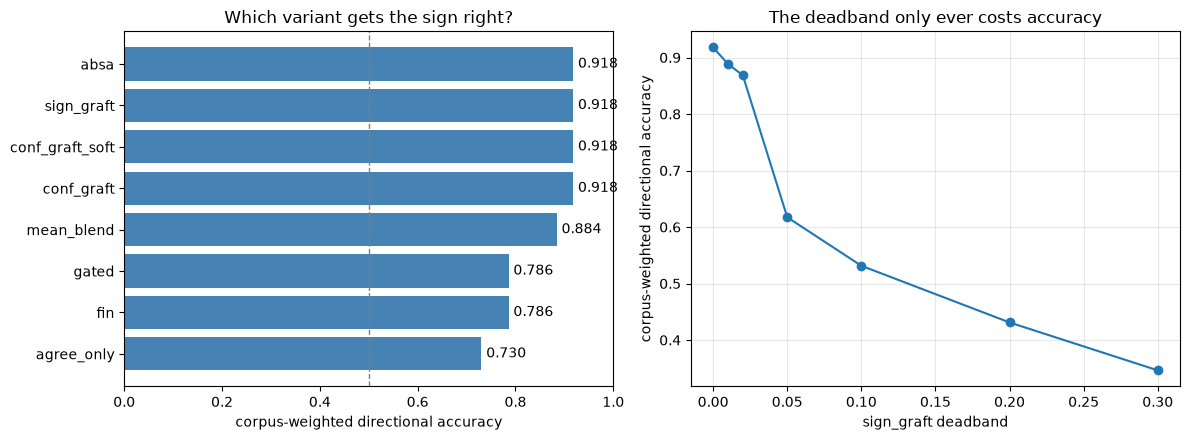

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = results.sort_values("corpus_dir_acc")
axes[0].barh(order.index, order["corpus_dir_acc"], color="steelblue")
axes[0].axvline(0.5, ls="--", lw=1, color="grey")
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("corpus-weighted directional accuracy")
axes[0].set_title("Which variant gets the sign right?")
for i, (name, row) in enumerate(order.iterrows()):
    axes[0].text(row["corpus_dir_acc"] + 0.01, i, f"{row['corpus_dir_acc']:.3f}", va="center")

sw = pd.DataFrame(sweep)
axes[1].plot(sw["deadband"], sw["corpus_dir_acc"], marker="o")
axes[1].set_xlabel("sign_graft deadband")
axes[1].set_ylabel("corpus-weighted directional accuracy")
axes[1].set_title("The deadband only ever costs accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS_DIR / "figures" / "2.4-fusion-accuracy.png", dpi=120)
plt.show()

### 10. Are the labels any good?

We measured everything above against 300 judgements made by one annotator who also designed the
variants, and with a single annotator we have no way to know how subjective the task is. If two
careful annotators would only agree 80% of the time, a variant scoring 0.918 is at the ceiling and
the fine distinctions between the leaders are noise.

So the same 300 sentences were labelled twice more, by two annotators working from
`references/fusion-labelling-protocol.md` alone, blind to every model score, to the existing labels,
and to the fact that scoring variants were being evaluated at all.

Both are LLM annotators, and that limits what the result can mean. They are not independent human
validation, and nothing here establishes that any label set is more accurate than another, since
there is no external ground truth. What three label sets buy is an estimate of how tightly the
protocol constrains the task, an estimate of the ceiling, and the ability to recompute every
headline against labels the first annotator did not write.

In [21]:
raters = {"me": "fusion-labels.csv", "llm_a": "fusion-labels-llm-a.csv",
          "llm_b": "fusion-labels-llm-b.csv"}
lab = df[["sample_id", "stratum"] + list(VARIANTS)].copy()
for name, fn in raters.items():
    lab = lab.merge(pd.read_csv(PROJ_ROOT / "references" / fn)
                    .rename(columns={"label": f"lab_{name}"}), on="sample_id", how="left")

print("label distributions:")
print(pd.DataFrame({n: lab[f"lab_{n}"].value_counts().sort_index() for n in raters}).to_string())

label distributions:
       me  llm_a  llm_b
-1.0   53     23     17
-0.5   55     84     88
 0.0  110    100    104
 0.5   46     78     75
 1.0   36     15     16


In [22]:
def quadratic_kappa(a, b):
    """Cohen's kappa with quadratic weights -- the right statistic for an ordinal
    scale, since it penalises a +1.0/-1.0 clash far more than +1.0/+0.5."""
    cats = sorted(set(a) | set(b)); idx = {c: i for i, c in enumerate(cats)}; k = len(cats)
    O = np.zeros((k, k))
    for x, y in zip(a, b):
        O[idx[x], idx[y]] += 1
    O /= O.sum()
    ha = np.array([np.mean([idx[x] == i for x in a]) for i in range(k)])
    hb = np.array([np.mean([idx[y] == i for y in b]) for i in range(k)])
    Wt = np.array([[((i - j) / (k - 1)) ** 2 for j in range(k)] for i in range(k)])
    return 1 - (Wt * O).sum() / (Wt * np.outer(ha, hb)).sum()

import itertools
rows = []
for x, y in itertools.combinations(raters, 2):
    a, b = lab[f"lab_{x}"], lab[f"lab_{y}"]
    d, sd = a != b, np.sign(a) != np.sign(b)
    rows.append({"pair": f"{x} vs {y}", "exact": (a == b).mean(),
                 "sign": (np.sign(a) == np.sign(b)).mean(),
                 "quad_kappa": quadratic_kappa(list(a), list(b)),
                 "disagree_on_sign": int(sd.sum()),
                 "disagree_on_intensity_only": int((d & ~sd).sum())})
pd.DataFrame(rows).set_index("pair").round(3)

,exact,sign,quad_kappa,disagree_on_sign,disagree_on_intensity_only
pair,,,,,
me vs llm_a,0.637,0.817,0.800,55,54
me vs llm_b,0.660,0.853,0.856,44,58
llm_a vs llm_b,0.833,0.860,0.870,42,8


Three things fall out of this for us.

The protocol is tightly specified. Quadratic-weighted kappa runs 0.80 to 0.87 across all three
pairs, so the labels follow from the written rules rather than from one annotator's private
expectations.

The two LLM annotators are visibly not independent of each other. They agree with each other on
83.3% of labels exactly, while agreeing with the first annotator on only 63.7% and 66.0%. Same
model family, same clustering. They are independent of the first annotator's labels rather than of
its reasoning, and a second human would not cluster like this.

The disagreements are mostly about intensity rather than direction. Roughly half of them are
intensity-only, and the LLM annotators use the half-points far more and the extremes far less,
placing 5 to 8% of sentences at plus or minus 1.0 against the first annotator's 30%. The scale is
being applied on a different internal calibration while direction largely survives.

In [23]:
all_agree = ((np.sign(lab["lab_me"]) == np.sign(lab["lab_llm_a"]))
             & (np.sign(lab["lab_llm_a"]) == np.sign(lab["lab_llm_b"])))
print(f"all three annotators agree on SIGN: {int(all_agree.sum())} of {len(lab)} "
      f"({100*all_agree.mean():.1f}%)")
print()
print("This is the CEILING. No scorer can be judged correct on sentences the")
print("annotators themselves cannot agree about.")

all three annotators agree on SIGN: 232 of 300 (77.3%)

This is the CEILING. No scorer can be judged correct on sentences the
annotators themselves cannot agree about.


In [24]:
POP_W = {"absa_flat": 4233, "agree_strong": 3186, "disagree_plain": 2756,
         "agree_weak": 1861, "resolved": 1277, "disagree_comparative": 634}
_t = sum(POP_W.values()); POP_W = {k: v / _t for k, v in POP_W.items()}

def acc_against(col, labcol):
    d = lab[lab[labcol] != 0]
    return sum(POP_W[st] * (np.sign(g[col]) == np.sign(g[labcol])).mean()
               for st, g in d.groupby("stratum"))

acc = pd.DataFrame({n: {v: acc_against(v, f"lab_{n}") for v in VARIANTS} for n in raters})
acc["spread_across_raters"] = acc.max(axis=1) - acc.min(axis=1)
acc.sort_values("me", ascending=False).round(3)

,me,llm_a,llm_b,spread_across_raters
absa,0.918,0.905,0.928,0.023
sign_graft,0.918,0.905,0.928,0.023
conf_graft_soft,0.918,0.905,0.928,0.023
conf_graft,0.918,0.905,0.928,0.023
mean_blend,0.884,0.888,0.892,0.008
fin,0.786,0.804,0.795,0.018
gated,0.786,0.804,0.795,0.018
agree_only,0.730,0.733,0.740,0.010


The ranking is identical under all three label sets, and every variant moves by at most 0.023
depending on who labelled. The four ABSA-sign variants tie at 0.905 to 0.928, and they tie by
construction since none of them alters the sign, `mean_blend` sits at 0.884 to 0.892, and the two
FinBERT-sign variants at 0.786 to 0.804. The gap of around 12 points between ABSA-sign and
FinBERT-sign variants survives intact under every annotator, and it is the central claim of the
notebook.

With annotators agreeing on sign for only 232 of the 300 sentences, a claim of the form "variant X
beats variant Y by 3 points" is not supportable, because that difference is smaller than the
disagreement between the people doing the measuring. Concretely, the separation between
`conf_graft` at Spearman 0.760 and `absa` at 0.730 is undefended. What survives comfortably is the
12-point direction gap, which is roughly four times the between-annotator variation.

In [25]:
print("magnitude finding recomputed -- rho(|score|, |label|) on rows where")
print("fin AND absa both have the correct sign, so only the magnitude differs\n")
out = []
for n in raters:
    lc = f"lab_{n}"
    d = lab[lab[lc] != 0]
    common = d[(np.sign(d["fin"]) == np.sign(d[lc])) & (np.sign(d["absa"]) == np.sign(d[lc]))]
    out.append({"rater": n, "n": len(common),
                "finbert_magnitude": spearmanr(common["fin"].abs(), common[lc].abs()).statistic,
                "absa_magnitude": spearmanr(common["absa"].abs(), common[lc].abs()).statistic})
mag_check = pd.DataFrame(out).set_index("rater")
mag_check["gap"] = mag_check["finbert_magnitude"] - mag_check["absa_magnitude"]
mag_check.round(3)

magnitude finding recomputed -- rho(|score|, |label|) on rows where
fin AND absa both have the correct sign, so only the magnitude differs



,n,finbert_magnitude,absa_magnitude,gap
rater,,,,
me,119,0.461,0.298,0.163
llm_a,126,0.412,0.135,0.278
llm_b,130,0.490,0.171,0.319


This result rebuts our own caveat. The worry with LLM annotators was that one asked what the
sentiment toward Tesla is, is doing essentially ABSA's task with a bigger model, so ABSA might be
flattered by shared inductive bias.

The opposite happened. Against the two LLM annotators ABSA's magnitude correlation falls to 0.135
and 0.171, far below the 0.298 it scored against the first annotator, while FinBERT holds at 0.412
to 0.490. The measured gap widens from 0.163 to 0.278 and 0.319. So the second half of the
hypothesis comes out of this check stronger than it went in, and the flattery concern is not merely
unproven but points the wrong way.

### 11. Verdict

The hypothesis was that attribution and intensity are separable and come from different models, and
both halves are confirmed on independent evidence. Direction belongs to ABSA, at 0.918 against
0.786 corpus-weighted and 90% against 10% on the comparative disagreements. Magnitude belongs to
FinBERT, at rho 0.461 against 0.298, AUC 0.769 against 0.674, 0.513 against 0.193 on the finer
by-eye ranking, and extremes that pick out earnings and deliveries rather than "the ladies in my
house love it". Neither model is good at both.

| variant | direction | Spearman | magnitude (rho) | extreme prec. | shout-right | noise on neutrals | dyn. range |
|---|---|---|---|---|---|---|---|
| `conf_graft` | 0.918 | 0.760 | 0.465 | 0.90 | 2.55 | 0.052 | 0.672 |
| `conf_graft_soft` | 0.918 | 0.739 | 0.485 | 0.90 | 1.61 | 0.154 | 0.993 |
| `absa` | 0.918 | 0.730 | 0.298 | 0.75 | 1.87 | 0.176 | 0.979 |
| `sign_graft` | 0.918 | 0.724 | 0.461 | 0.85 | 1.39 | 0.256 | 1.315 |
| `agree_only` | 0.730 | 0.717 | 0.461 | 0.95 | artefact | 0.193 | 1.240 |
| `mean_blend` | 0.884 | 0.708 | 0.504 | 0.95 | 1.99 | 0.199 | 1.072 |
| `fin` | 0.786 | 0.528 | 0.461 | 0.90 | 2.02 | 0.256 | 1.165 |
| `gated` | 0.786 | 0.459 | 0.443 | 0.85 | 2.26 | 0.068 | 0.595 |

Four variants tie at the top on direction, because all four take ABSA's sign and none of them can
alter it, so direction no longer separates the leaders and the choice comes down to magnitude
behaviour and to how each one behaves on its mistakes.

`conf_graft` is the best-behaved variant we have and it is the one we adopt. It has the best overall
Spearman of all eight, ties the top on direction, has the best shout-when-right ratio at 2.55, has
the best error amplification of anything tested including both of its parents at 0.393, and is the
quietest of all eight on neutral sentences at 0.052, which matters because neutral sentences are
37% of the sample and every one of them is noise fed into an article mean. Its one weakness is the
narrow dynamic range.

Two of our own design decisions did not survive. `gated`, which we argued was the most principled
variant, is structurally incapable of helping, and the deadband, which we added to make
`sign_graft` safer, was its single biggest weakness.

`mean_blend` is the honourable mention. We included it as a strawman to embarrass the clever
variants, and it still finishes best on magnitude at 0.504 and tied-best on extreme precision, for
3.4 points of direction, which is roughly six sentences and inside the noise. We recommended
carrying it alongside and never did. Notebook 2.3 section 1 declined it, and `AGGREGATED_VARIANTS`
has never contained it.

### 12. The floor: `CONF_FLOOR = 0.7`

Everything above measures which construction to use. This section measures how loud it is, which
nothing above tested, and it changes what the pipeline ships.

We started from hand inspection rather than a metric, having noticed that strictly financial
sentences were scoring weaker than they read. `conf_graft` is `absa * |fin|`, which is algebraically
`sign(absa) * |fin| * |absa|`, and that third term acts as a confidence multiplier, so a lukewarm
ABSA call at `|absa| = 0.3` discards 70% of FinBERT's magnitude before the price model ever sees it.

All three conf-graft variants are one expression at different settings:

```
sign(absa) * |fin| * (floor + (1 - floor) * |absa|)
```

A floor of 0.0 gives `conf_graft`, 0.5 gives `conf_graft_soft`, 0.7 gives `conf_graft_floor` which
is what ships, and 1.0 gives `sign_graft` with FinBERT's magnitude kept in full. So weighting
FinBERT more heavily against ABSA is not a redesign, it is choosing a point on a line that was
already there. No value of the floor can change any row's sign, which is what keeps the referent
verdicts in 2.1 valid across the whole sweep.

We swept the floor against the 2,500 clean rows of the full-corpus score audit, sheets 01,
03, 04, 05 and 07. Sheets 02 and 06 are excluded, because they
applied a divergent rule that filed every `|cg| < 0.05` row as `benign` regardless of referent, 407
rows sharing one identical reason string. We report the share of total sentiment mass carried by
each verdict class rather than headcount, because the earlier impact audit established that harmful
rows are 2.4 times over-represented by magnitude. The run is recorded in
`notebooks/fusion-weight-sweep.txt`.

| floor | mean \|score\| | correct | benign | minor | implausible | harmful | SNR |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.00 | 0.201 | 87.39 | 1.72 | 0.32 | 8.33 | 2.24 | 6.931 |
| 0.50 | 0.360 | 87.81 | 2.92 | 0.89 | 6.41 | 1.98 | 7.201 |
| 0.70 | 0.423 | 87.89 | 3.14 | 0.99 | 6.05 | 1.93 | 7.254 |
| 1.00 | 0.518 | 87.97 | 3.38 | 1.11 | 5.67 | 1.88 | 7.311 |

Raising the floor improves both error classes, which is the opposite of what we expected, and the
reason is a real property of ABSA on this corpus that we had not seen before:

| verdict | n | mean \|absa\| | mean `absa_neu` | mean \|cg\| |
|---|---:|---:|---:|---:|
| `correct` | 2188 | 0.327 | 0.637 | 0.201 |
| `implausible` | 95 | 0.578 | 0.346 | 0.440 |
| `harmful` | 34 | 0.490 | 0.434 | 0.331 |
| `benign` | 155 | 0.182 | 0.783 | 0.056 |

ABSA is more confident on the rows it gets wrong than on the rows it gets right, so the confidence
multiplier is anti-correlated with correctness. At floor 0 the wrong rows already sat near full
magnitude and had little to gain, while the correct rows were the ones being crushed, and raising
the floor hands most of the restored magnitude to them.

We pay a real cost for it. Off-target rows are the quietest of all, at a mean `|absa|` of 0.182, so they gain
the most in relative terms, and the share of `benign` rows held under `|cg| < 0.05` falls from 0.83
at floor 0.0 to 0.43 at floor 0.7. Publisher boilerplate and off-referent text that ABSA was
silencing by accident becomes audible. That is a genuine regression and it is why we ship at 0.7
rather than 1.0. The publisher-boilerplate blocklist described in 2.0 section 4 is the principled
fix for it, not a lower floor.

We tested and rejected one alternative, gating the floor on `absa_neu` so that full FinBERT
magnitude applies only where ABSA says the sentence is about the aspect. It keeps `benign` rows
silenced, at 0.78 under 0.05, but drops SNR to 6.30, which is worse than doing nothing, because
`implausible` rows carry the lowest `absa_neu` of any class at 0.346. Any rule of the form "trust
ABSA when it is confident" amplifies precisely the errors. The smooth variant
`floor = 0.7 * (1 - absa_neu)` gives 6.60, also below baseline.

`CONF_FLOOR = 0.7` ships as `conf_graft_floor`. Mean `|score|` goes from 0.201 to 0.423, dynamic
range from roughly 0.67 to 1.1, `implausible` mass from 8.33% to 6.05%, `harmful` mass from 2.24%
to 1.93%, and SNR up 4.7%. This is a modest gain and we should not oversell it. The floor sat at a
value nobody had tested, testing it found a better one, and the better one is only slightly better.

The audit itself was eight sheets of 500 rows drawn from the scored corpus, of which five are
clean. Its composition, since the sheets are not kept: over the 2,500 clean rows
the split is 87.52% `correct`, 6.20% `benign`, 1.12% `minor`, 3.80% `implausible` and 1.36%
`harmful`, and the error rate is not evenly spread across the provenance channels of 2.1.

- **`surface`**: 2,119 of the 2,500 rows, 5.43% `implausible` or `harmful`.
- **`coref_span`**: 330 rows, 3.94%.
- **`coref_nospan`**: 51 rows, 1.96%.

Surface carries both the bulk of the corpus and the highest error rate, which agrees with the
separate per-channel audit in 2.1 section 5 and is the reason the residual error budget is now a
surface problem rather than a coreference one.

Sheet 08 was drawn after the floor moved to 0.7 and is not part of the sweep above. It is not
comparable to the other seven: only 18.6% of its rows sit under `|cg| < 0.05` against 42% to 52%
for the rest, which is the raised floor showing up in the sample rather than any change in quality.

The labelling throughout was done by a model rather than a person, so every figure in this section
is a model auditing another model's output.

### 13. Limitations

- Every number we have is agreement with a careful reader rather than a return. It is entirely
  possible for the better-attributed score to be the worse predictor, and nothing in this project
  tests that yet.
- The 77.3% ceiling caps the resolution, so only the 12-point direction gap is defended.
- 300 sentences across six strata, reweighted, means the corpus-weighted numbers inherit the noise
  of 50-row estimates. `disagree_comparative` carries only 4.5% of the corpus weight, so its
  dramatic 0.103 against 0.897 split moves the headline less than it appears to.
- Neutral sentences are 37% of the sample and are excluded from directional accuracy by
  construction. `mean_abs_on_neutral` is the only column that speaks to them, and `gated` wins it
  decisively, which is a genuine virtue this notebook otherwise gives it no credit for.
- The deadband sweep was run after the variants were specified, so the zero result is a post-hoc
  fix rather than a pre-registered prediction. It is large, monotonic and mechanistically
  explained, but we found it by looking rather than by predicting it.
- `CONF_FLOOR` rests on 34 harmful and 95 implausible rows, and the verdicts were assigned while
  looking at the floor-0 score, so `minor` against `harmful` is approximate near that boundary. The
  full-corpus audit stalled at 23.2% coverage, and 2.3 section 9 covers why more labelling is hard.